# Phase 1: Ingestion Pipeline

In this notebook I build Phase 1 of my Kubernetes security RAG system as a standalone notebook. I want this file to run locally and in Google Colab without depending on separate project modules.

This phase covers:
1. live scraping from trusted sources
2. normalization into one document schema
3. sentence-aware chunking
4. embedding generation
5. Chroma vector storage


## How I Run This Notebook

I use this notebook as the main Phase 1 record for the project.

Main steps:
1. I run the first code cell to enforce the pinned package versions.
2. If I am in Colab and the first cell installs packages, I restart the runtime once.
3. I rerun the notebook from the top.
4. I let the notebook finish the full pipeline and save analysis outputs to the `output/` folder.


In [1]:
import importlib.metadata as importlib_metadata
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
PINNED_PACKAGES = [
    'requests==2.32.3',
    'beautifulsoup4==4.12.3',
    'lxml==5.2.2',
    'matplotlib==3.9.0',
    'pypdf==4.2.0',
    'pandas==2.2.2',
    'numpy==1.26.4',
    'sentence-transformers==3.0.1',
    'transformers==4.46.3',
    'tokenizers==0.20.3',
    'huggingface-hub==0.36.2',
    'chromadb==0.5.23',
]
EXPECTED_VERSIONS = {
    'requests': '2.32.3',
    'beautifulsoup4': '4.12.3',
    'lxml': '5.2.2',
    'matplotlib': '3.9.0',
    'pypdf': '4.2.0',
    'pandas': '2.2.2',
    'numpy': '1.26.4',
    'sentence-transformers': '3.0.1',
    'transformers': '4.46.3',
    'tokenizers': '0.20.3',
    'huggingface-hub': '0.36.2',
    'chromadb': '0.5.23',
}

def get_installed_version(package_name: str) -> str | None:
    try:
        return importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        return None

current_versions = {name: get_installed_version(name) for name in EXPECTED_VERSIONS}
needs_install = any(current_versions[name] != EXPECTED_VERSIONS[name] for name in EXPECTED_VERSIONS)

print('Current package versions:')
for name, expected in EXPECTED_VERSIONS.items():
    print(f'- {name}: installed={current_versions[name]} expected={expected}')

if IN_COLAB and needs_install:
    print()
    print('Installing pinned package versions for Colab compatibility...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *PINNED_PACKAGES])
    raise SystemExit('Pinned packages installed. Please restart the Colab runtime, then run the notebook again from the top.')
elif needs_install:
    print()
    print('Some local package versions do not match the notebook pins. The local run can still continue if imports work, but the pinned environment is recommended.')
else:
    print()
    print('Pinned package versions are already active.')


Current package versions:
- requests: installed=2.32.3 expected=2.32.3
- beautifulsoup4: installed=4.12.3 expected=4.12.3
- lxml: installed=5.2.2 expected=5.2.2
- matplotlib: installed=3.9.0 expected=3.9.0
- pypdf: installed=4.2.0 expected=4.2.0
- pandas: installed=2.2.2 expected=2.2.2
- numpy: installed=1.26.4 expected=1.26.4
- sentence-transformers: installed=3.0.1 expected=3.0.1
- transformers: installed=4.46.3 expected=4.46.3
- tokenizers: installed=0.20.3 expected=0.20.3
- huggingface-hub: installed=0.36.2 expected=0.36.2
- chromadb: installed=0.5.23 expected=0.5.23

Pinned package versions are already active.


## Why The Helper Code Is Inside The Notebook

I keep the helper code inside this notebook for two reasons.

1. I want the notebook to be self-contained, so I can move it to Colab without copying extra Python files.
2. I want the in-person demo to show the full Phase 1 logic in one place.

I still separate the helper code by task so the notebook stays readable.


In [2]:
# Text and identifier helpers used across the full pipeline.


import re
from urllib.parse import urlparse


def slugify(value: str) -> str:
    value = value.lower().strip()
    value = re.sub(r"[^a-z0-9]+", "_", value)
    value = re.sub(r"_+", "_", value)
    return value.strip("_") or "untitled"


def url_to_slug(url: str) -> str:
    parsed = urlparse(url)
    path = parsed.path.strip("/")
    if not path:
        path = "root"
    if parsed.query:
        path = f"{path}_{parsed.query}"
    return slugify(path)


from datetime import datetime, timezone


def utc_now() -> datetime:
    return datetime.now(timezone.utc)


def utc_now_iso() -> str:
    return utc_now().replace(microsecond=0).isoformat().replace("+00:00", "Z")


def make_snapshot_id() -> str:
    return utc_now().strftime("%Y-%m-%dT%H%M%SZ")


from pathlib import Path


def get_project_root(start: Path | None = None) -> Path:
    """Return the project root regardless of whether code runs from the repo or notebooks."""
    candidate = (start or Path.cwd()).resolve()
    if candidate.name == "notebooks":
        return candidate.parent
    return candidate


def build_paths(root: Path) -> dict[str, Path]:
    data_root = root / "data"
    vector_store_root = data_root / "vector_store"
    return {
        "root": root,
        "config": root / "config",
        "notebooks": root / "notebooks",
        "src": root / "src",
        "data": data_root,
        "raw": data_root / "raw",
        "normalized": data_root / "normalized",
        "chunks": data_root / "chunks",
        "embeddings": data_root / "embeddings",
        "vector_store": vector_store_root,
        "chroma": vector_store_root / "chroma",
        "manifests": data_root / "manifests",
    }


def ensure_directories(paths: dict[str, Path]) -> None:
    for key, path in paths.items():
        if key == "root":
            continue
        if path.suffix:
            continue
        path.mkdir(parents=True, exist_ok=True)


import json
from pathlib import Path
from typing import Iterable


def write_jsonl(path: Path, rows: Iterable[dict], mode: str = "w") -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open(mode, encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, ensure_ascii=False) + "\n")


import hashlib


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


import platform
import sys
from importlib.metadata import PackageNotFoundError, version


def collect_environment_report(packages: list[str]) -> dict[str, object]:
    package_versions: dict[str, str] = {}
    for package in packages:
        try:
            package_versions[package] = version(package)
        except PackageNotFoundError:
            package_versions[package] = "not installed"

    return {
        "python_version": sys.version.split()[0],
        "platform": platform.platform(),
        "packages": package_versions,
    }


In [3]:
# Snapshot and artifact saving helpers keep the pipeline reproducible.


import json
from pathlib import Path
from urllib.parse import urlparse



def infer_extension(content_type: str, url: str) -> str:
    lowered = content_type.lower()
    if "html" in lowered:
        return ".html"
    if "json" in lowered:
        return ".json"
    if "pdf" in lowered:
        return ".pdf"

    suffix = Path(urlparse(url).path).suffix
    return suffix if suffix else ".bin"


def save_raw_snapshot(
    raw_root: Path,
    source_id: str,
    snapshot_id: str,
    fetch_result: dict,
    item_id: str | None = None,
) -> dict:
    safe_item_id = slugify(item_id) if item_id else url_to_slug(fetch_result["final_url"])
    snapshot_dir = raw_root / source_id / snapshot_id / safe_item_id
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    extension = infer_extension(fetch_result["content_type"], fetch_result["final_url"])
    body_path = snapshot_dir / f"body{extension}"
    body_bytes = fetch_result["body_bytes"]
    body_path.write_bytes(body_bytes)

    metadata = {
        "snapshot_id": snapshot_id,
        "source_id": source_id,
        "item_id": safe_item_id,
        "url": fetch_result["final_url"],
        "requested_url": fetch_result["requested_url"],
        "fetched_at": fetch_result["fetched_at"],
        "status_code": fetch_result["status_code"],
        "content_type": fetch_result["content_type"],
        "encoding": fetch_result["encoding"],
        "sha256": sha256_bytes(body_bytes),
        "byte_size": len(body_bytes),
        "local_body_path": str(body_path),
        "headers": fetch_result["headers"],
    }

    metadata_path = snapshot_dir / "metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    metadata["metadata_path"] = str(metadata_path)
    return metadata


def save_normalized_documents(normalized_root: Path, snapshot_id: str, source_id: str, documents: list[dict]) -> Path:
    snapshot_dir = normalized_root / snapshot_id
    snapshot_dir.mkdir(parents=True, exist_ok=True)
    target_path = snapshot_dir / f"{slugify(source_id)}.jsonl"
    write_jsonl(target_path, documents, mode="w")
    return target_path


def save_chunk_records(chunks_root: Path, snapshot_id: str, chunks: list[dict]) -> Path:
    snapshot_dir = chunks_root / snapshot_id
    snapshot_dir.mkdir(parents=True, exist_ok=True)
    target_path = snapshot_dir / "chunks.jsonl"
    write_jsonl(target_path, chunks, mode="w")
    return target_path


In [4]:
# Fetch helpers enforce the source allowlist and keep the live collection step controlled.


from urllib.parse import urlparse

import requests


BROWSER_HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/136.0.0.0 Safari/537.36"
    ),
    "Accept": (
        "text/html,application/xhtml+xml,application/xml;q=0.9,"
        "application/pdf;q=0.8,*/*;q=0.7"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Cache-Control": "no-cache",
    "Pragma": "no-cache",
}

MINIMAL_HEADERS = {
    "User-Agent": "rag-k8s-security/0.1 (+assignment ingestion pipeline)",
}

HEADER_PROFILES = (BROWSER_HEADERS, MINIMAL_HEADERS)


def validate_allowed_domain(url: str, allowed_domains: list[str]) -> None:
    host = (urlparse(url).hostname or "").lower()
    if not any(host == domain or host.endswith(f".{domain}") for domain in allowed_domains):
        raise ValueError(f"URL host '{host}' is not in the allowed domain list: {allowed_domains}")


def fetch_url(url: str, allowed_domains: list[str], timeout: int = 30) -> dict:
    validate_allowed_domain(url, allowed_domains)

    last_error: requests.HTTPError | None = None
    response: requests.Response | None = None

    for headers in HEADER_PROFILES:
        response = requests.get(url, timeout=timeout, headers=headers)
        try:
            response.raise_for_status()
            break
        except requests.HTTPError as exc:
            last_error = exc
            if response.status_code != 403:
                raise
    else:
        assert last_error is not None
        raise last_error

    assert response is not None

    return {
        "requested_url": url,
        "final_url": response.url,
        "fetched_at": utc_now_iso(),
        "status_code": response.status_code,
        "headers": dict(response.headers),
        "content_type": response.headers.get("Content-Type", "application/octet-stream"),
        "encoding": response.encoding,
        "body_bytes": response.content,
    }


In [5]:
# HTML normalization keeps section structure when the source is a web page.


import re
from typing import Iterable

from bs4 import BeautifulSoup, Tag


HEADING_TAGS = {"h1", "h2", "h3", "h4"}
TEXT_TAGS = {"p", "li", "pre", "code"}
DROP_TAGS = {"script", "style", "noscript", "svg", "header", "footer", "nav", "form"}
META_UPDATED_KEYS = (
    "article:modified_time",
    "og:updated_time",
    "last-modified",
    "date",
    "dc.date.modified",
)
PILCROW_RE = re.compile(r"\s*¶\s*")
TRAILING_DASH_RE = re.compile(r"\s*--+\s*$")
LOW_SIGNAL_HEADING_RE = re.compile(r"\b(feedback|page status|what'?s next|references)\b", re.IGNORECASE)
LOW_SIGNAL_TEXT_RE = re.compile(
    r"(was this page helpful\?|thanks for the feedback|open an issue in the github repository|ask it on stack overflow)",
    re.IGNORECASE,
)


def collapse_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def clean_html_text(text: str) -> str:
    cleaned = PILCROW_RE.sub(" ", text)
    cleaned = TRAILING_DASH_RE.sub("", cleaned)
    cleaned = collapse_whitespace(cleaned)
    cleaned = re.sub(r"\s+([.,;:!?])", r"\1", cleaned)
    return cleaned


def dedupe_consecutive_items(items: list[str]) -> list[str]:
    deduped: list[str] = []
    previous_normalized: str | None = None

    for item in items:
        normalized = clean_html_text(item)
        if not normalized:
            continue
        if normalized == previous_normalized:
            continue
        deduped.append(normalized)
        previous_normalized = normalized

    return deduped


def is_low_signal_section(section_path: list[str], text: str) -> bool:
    joined_headings = " > ".join(section_path)
    if LOW_SIGNAL_HEADING_RE.search(joined_headings):
        return True
    if LOW_SIGNAL_TEXT_RE.search(text):
        return True
    return False


def extract_updated_at(soup: BeautifulSoup) -> str | None:
    for key in META_UPDATED_KEYS:
        tag = soup.find("meta", attrs={"property": key}) or soup.find("meta", attrs={"name": key})
        if tag and tag.get("content"):
            return collapse_whitespace(tag["content"])

    time_tag = soup.find("time")
    if time_tag and time_tag.get("datetime"):
        return collapse_whitespace(time_tag["datetime"])
    return None


def iter_content_nodes(root: Tag) -> Iterable[Tag]:
    for node in root.descendants:
        if not isinstance(node, Tag):
            continue
        if node.name in HEADING_TAGS or node.name in TEXT_TAGS:
            yield node


def parse_html_sections(
    html_text: str,
    source_id: str,
    source_url: str,
    trust_level: str,
    topic_tags: list[str],
    document_key: str | None = None,
) -> list[dict]:
    soup = BeautifulSoup(html_text, "lxml")

    for tag_name in DROP_TAGS:
        for tag in soup.find_all(tag_name):
            tag.decompose()

    root = soup.find("main") or soup.find("article") or soup.body or soup
    page_title = clean_html_text((soup.title.string if soup.title and soup.title.string else "Untitled Page"))
    top_heading = root.find("h1")
    document_title = clean_html_text(top_heading.get_text(" ", strip=True)) if top_heading else page_title
    updated_at = extract_updated_at(soup)
    page_key = slugify(document_key) if document_key else url_to_slug(source_url)

    documents: list[dict] = []
    headings: dict[int, str] = {}
    buffer: list[str] = []
    section_counter = 0

    def current_section_path() -> list[str]:
        ordered = [headings[level] for level in sorted(headings)]
        return ordered or [document_title]

    def flush_section() -> None:
        nonlocal section_counter, buffer
        text = clean_html_text(" ".join(dedupe_consecutive_items(buffer)))
        if len(text) < 40:
            buffer = []
            return

        section_counter += 1
        section_path = current_section_path()
        if is_low_signal_section(section_path, text):
            buffer = []
            return
        slug = "__".join(slugify(part) for part in section_path)
        documents.append(
            {
                "doc_id": f"{slugify(source_id)}__{page_key}__{slug}__{section_counter:04d}",
                "snapshot_id": None,
                "source_id": source_id,
                "page_key": page_key,
                "doc_kind": "guide_section",
                "external_id": None,
                "title": document_title,
                "section_path": section_path,
                "source_url": source_url,
                "published_at": None,
                "updated_at": updated_at,
                "page_number": None,
                "trust_level": trust_level,
                "topic_tags": topic_tags,
                "text": text,
            }
        )
        buffer = []

    for node in iter_content_nodes(root):
        node_text = clean_html_text(node.get_text(" ", strip=True))
        if not node_text:
            continue

        if node.name in HEADING_TAGS:
            flush_section()
            level = int(node.name[1])
            headings[level] = node_text
            for deeper_level in list(headings):
                if deeper_level > level:
                    headings.pop(deeper_level, None)
            continue

        if node.name in TEXT_TAGS:
            buffer.append(node_text)

    flush_section()
    return documents


# PDF normalization removes boilerplate and keeps page-level text where useful.


import re
from collections import Counter
from io import BytesIO
from pathlib import Path
from urllib.parse import urlparse

from pypdf import PdfReader



NSA_HEADER_RE = re.compile(r"u/oo/168286|pp-22-0324|august 2022 ver\.?|version 1\.?2", re.IGNORECASE)
AGENCY_RE = re.compile(
    r"national security agency|cybersecurity and infrastructure security agency|kubernetes hardening guid",
    re.IGNORECASE,
)
DOT_LEADER_RE = re.compile(r"\.{3,}")
PAGE_ONLY_RE = re.compile(r"^[ivxlcdm0-9]+$", re.IGNORECASE)
PUNCT_ONLY_RE = re.compile(r"^[^\w]+$")
TRAILING_DASH_RE = re.compile(r"\s*--+\s*$")
INDEX_REF_RE = re.compile(r",\s*\d{1,3}(?:-\d{1,3})?\b")
REFERENCES_RE = re.compile(r"\b(references|bibliography)\b", re.IGNORECASE)
COLLOPHON_RE = re.compile(r"\b(about the author|colophon|acknowledg?ments?)\b", re.IGNORECASE)
ABBREVIATIONS_RE = re.compile(r"\b(symbols and abbreviations|abbreviations)\b", re.IGNORECASE)
THESIS_FRONT_MATTER_RE = re.compile(
    r"\b(master'?s thesis|licensed under a creative commons|preface)\b",
    re.IGNORECASE,
)
BOOK_BACK_MATTER_RE = re.compile(
    r"\b(other books you may enjoy|leave a review|about the reviewers|contributors|about the authors)\b",
    re.IGNORECASE,
)
PACKT_FRONT_MATTER_RE = re.compile(
    r"\b(packt\.com subscribe|first published:|published by packt publishing|foreword)\b",
    re.IGNORECASE,
)
REDHAT_MARKETING_RE = re.compile(
    r"\b(about red hat|redhat\.com|red hat openshift provides a full featured technology stack)\b",
    re.IGNORECASE,
)


def collapse_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def clean_pdf_text(text: str) -> str:
    cleaned = text.replace("\x17", " ").replace("ﬁ", "fi").replace("ﬂ", "fl")
    cleaned = re.sub(r"(?<=[A-Za-z])-\s+(?=[A-Za-z])", "", cleaned)
    cleaned = collapse_whitespace(cleaned)
    cleaned = TRAILING_DASH_RE.sub("", cleaned)
    cleaned = re.sub(r"\s+([.,;:!?])", r"\1", cleaned)
    return cleaned


def infer_pdf_title(reader: PdfReader, source_url: str) -> str:
    metadata = reader.metadata or {}
    raw_title = metadata.get("/Title") if hasattr(metadata, "get") else None
    if raw_title:
        return clean_pdf_text(str(raw_title))

    file_name = Path(urlparse(source_url).path).name or "Untitled PDF"
    return clean_pdf_text(file_name)


def normalize_pdf_line(line: str) -> str:
    return clean_pdf_text(line.replace("\x00", " "))


def extract_page_lines(raw_page_text: str) -> list[str]:
    return [normalize_pdf_line(line) for line in raw_page_text.splitlines() if normalize_pdf_line(line)]


def build_repeated_line_counts(page_lines: list[list[str]]) -> Counter[str]:
    counts: Counter[str] = Counter()
    for lines in page_lines:
        counts.update(set(lines))
    return counts


def is_pdf_boilerplate_line(line: str, repeated_counts: Counter[str], total_pages: int) -> bool:
    lowered = line.lower()
    if PAGE_ONLY_RE.fullmatch(line) or PUNCT_ONLY_RE.fullmatch(line):
        return True
    if DOT_LEADER_RE.search(line):
        return True
    if NSA_HEADER_RE.search(lowered):
        return True
    if AGENCY_RE.search(lowered) and repeated_counts.get(line, 0) >= max(3, total_pages // 12):
        return True
    if 0 < len(line) <= 14 and repeated_counts.get(line, 0) >= max(3, total_pages // 10):
        return True
    if repeated_counts.get(line, 0) >= max(5, total_pages // 8) and len(line) <= 120:
        return True
    return False


def is_table_of_contents_page(lines: list[str]) -> bool:
    if not lines:
        return False

    first_lines = " ".join(lines[:6]).lower()
    dot_lines = sum(1 for line in lines if DOT_LEADER_RE.search(line))
    short_lines = sum(1 for line in lines if len(line.split()) <= 10)

    if "contents" in first_lines and (dot_lines >= 2 or short_lines >= 8):
        return True
    return False


def is_index_page(lines: list[str], text: str) -> bool:
    lowered = text.lower()
    if "index |" not in lowered and not lowered.startswith("index "):
        return False

    page_ref_count = len(INDEX_REF_RE.findall(text))
    has_cross_refs = "see also" in lowered
    return page_ref_count >= 8 or has_cross_refs


def is_references_page(lines: list[str], text: str) -> bool:
    lowered = text.lower()
    if not REFERENCES_RE.search(" ".join(lines[:4])):
        return False

    url_count = text.lower().count("http://") + text.lower().count("https://")
    doi_count = lowered.count("doi")
    bracket_count = lowered.count("[") + lowered.count("]")
    return url_count >= 2 or doi_count >= 2 or bracket_count >= 6


def is_abbreviations_page(lines: list[str], text: str) -> bool:
    lowered = text.lower()
    if not ABBREVIATIONS_RE.search(" ".join(lines[:4])):
        return False

    acronym_like = sum(1 for token in text.split() if token.isupper() and 2 <= len(token) <= 8)
    return acronym_like >= 12


def is_packt_front_or_back_matter(page_number: int, text: str) -> bool:
    lowered = text.lower()
    if BOOK_BACK_MATTER_RE.search(lowered):
        return True
    if page_number <= 12 and PACKT_FRONT_MATTER_RE.search(lowered):
        return True
    if page_number <= 10 and "copyright ©" in lowered and "packt publishing" in lowered:
        return True
    if page_number <= 10 and "for my lovely wife" in lowered:
        return True
    return False


def is_redhat_back_matter(page_number: int, text: str) -> bool:
    lowered = text.lower()
    if page_number >= 16 and "copyright ©" in lowered:
        return True
    if page_number >= 15 and REDHAT_MARKETING_RE.search(lowered):
        return True
    return False


def is_cover_or_front_matter_page(page_number: int, lines: list[str], text: str) -> bool:
    lowered = text.lower()
    if page_number == 1 and "cybersecurity technical report" in lowered and "kubernetes hardening guid" in lowered:
        return True
    if is_table_of_contents_page(lines):
        return True
    if is_index_page(lines, text):
        return True
    if is_references_page(lines, text):
        return True
    if COLLOPHON_RE.search(lowered):
        return True
    if is_abbreviations_page(lines, text):
        return True
    if is_packt_front_or_back_matter(page_number, text):
        return True
    if is_redhat_back_matter(page_number, text):
        return True
    if page_number <= 8:
        if lowered.startswith("notices and history") or "document change history" in lowered:
            return True
        if lowered.startswith("publication information"):
            return True
        if lowered.startswith("figures ") or lowered.startswith("figures figure"):
            return True
        if THESIS_FRONT_MATTER_RE.search(lowered):
            return True
    if lowered.startswith("preface ") or lowered == "preface":
        return True
    return False


def parse_pdf_pages(
    pdf_bytes: bytes,
    source_id: str,
    source_url: str,
    trust_level: str,
    topic_tags: list[str],
    document_key: str | None = None,
    min_chars: int = 80,
) -> list[dict]:
    reader = PdfReader(BytesIO(pdf_bytes))
    document_title = infer_pdf_title(reader, source_url)
    page_key = slugify(document_key) if document_key else url_to_slug(source_url)

    raw_page_texts = [page.extract_text() or "" for page in reader.pages]
    page_lines = [extract_page_lines(raw_text) for raw_text in raw_page_texts]
    repeated_counts = build_repeated_line_counts(page_lines)
    total_pages = len(reader.pages)

    documents: list[dict] = []
    for page_number, lines in enumerate(page_lines, start=1):
        filtered_lines = [
            line
            for line in lines
            if not is_pdf_boilerplate_line(line, repeated_counts=repeated_counts, total_pages=total_pages)
        ]
        text = clean_pdf_text(" ".join(filtered_lines))
        if len(text) < min_chars:
            continue
        if is_cover_or_front_matter_page(page_number, filtered_lines, text):
            continue

        documents.append(
            {
                "doc_id": f"{slugify(source_id)}__{page_key}__page_{page_number:04d}",
                "snapshot_id": None,
                "source_id": source_id,
                "page_key": page_key,
                "doc_kind": "pdf_page",
                "external_id": None,
                "title": document_title,
                "section_path": [document_title, f"Page {page_number}"],
                "source_url": source_url,
                "published_at": None,
                "updated_at": None,
                "page_number": page_number,
                "trust_level": trust_level,
                "topic_tags": topic_tags,
                "text": text,
            }
        )

    return documents


# JSON feed normalization converts Kubernetes CVE items into the same schema.


import json
import re



def collapse_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def parse_kubernetes_cve_feed(
    feed_bytes: bytes,
    source_id: str,
    source_url: str,
    trust_level: str,
    topic_tags: list[str],
    document_key: str | None = None,
) -> list[dict]:
    payload = json.loads(feed_bytes.decode("utf-8"))

    feed_meta = payload.get("_kubernetes_io", {})
    feed_updated_at = feed_meta.get("updated_at")
    feed_title = collapse_whitespace(
        payload.get("title")
        or payload.get("description")
        or "Kubernetes Official CVE Feed"
    )
    page_key = slugify(document_key) if document_key else url_to_slug(source_url)

    documents: list[dict] = []
    for item in payload.get("items", []):
        item_id = collapse_whitespace(item.get("id") or "unknown_cve")
        summary = collapse_whitespace(item.get("summary") or "")
        content_text = collapse_whitespace(item.get("content_text") or "")
        status = collapse_whitespace(item.get("status") or "")
        published_at = item.get("date_published")
        issue_url = item.get("url")
        advisory_url = item.get("external_url")
        source_link = advisory_url or issue_url or source_url

        text_parts = [
            f"CVE ID: {item_id}",
            f"Summary: {summary}" if summary else "",
            f"Status: {status}" if status else "",
            content_text,
        ]
        text = collapse_whitespace(" ".join(part for part in text_parts if part))
        if len(text) < 40:
            continue

        section_path = [item_id]
        if summary:
            section_path.append(summary)

        documents.append(
            {
                "doc_id": f"{slugify(source_id)}__{page_key}__{slugify(item_id)}",
                "snapshot_id": None,
                "source_id": source_id,
                "page_key": page_key,
                "doc_kind": "cve_feed_item",
                "external_id": item_id,
                "title": feed_title,
                "section_path": section_path,
                "source_url": source_link,
                "published_at": published_at,
                "updated_at": feed_updated_at,
                "page_number": None,
                "trust_level": trust_level,
                "topic_tags": topic_tags,
                "text": text,
            }
        )

    return documents


In [6]:
# Chunking helpers create sentence-aware retrieval units from normalized documents.


import re


SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9(\"'])")
CLAUSE_SPLIT_RE = re.compile(r"(?<=[;:])\s+(?=[A-Z0-9(\"'])")
URL_RE = re.compile(r"https?://|www\.", re.IGNORECASE)
LOW_SIGNAL_SECTION_RE = re.compile(
    r"\b(references|what'?s next|what s next|table of contents|contents)\b",
    re.IGNORECASE,
)
NSA_HEADER_RE = re.compile(r"u/oo/168286|pp-22-0324|august 2022 ver", re.IGNORECASE)
INDEX_LIKE_RE = re.compile(r"\bindex\b|\bsee also\b", re.IGNORECASE)
PAGE_REF_RE = re.compile(r",\s*\d{1,3}(?:-\d{1,3})?\b")
BACK_MATTER_RE = re.compile(r"\b(about the author|colophon|acknowledg?ments?)\b", re.IGNORECASE)


def collapse_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


def split_into_sentences(text: str) -> list[str]:
    cleaned = collapse_whitespace(text)
    if not cleaned:
        return []

    sentences = [segment.strip() for segment in SENTENCE_SPLIT_RE.split(cleaned) if segment.strip()]
    return sentences if sentences else [cleaned]


def split_into_clauses(text: str) -> list[str]:
    cleaned = collapse_whitespace(text)
    if not cleaned:
        return []

    clauses = [segment.strip() for segment in CLAUSE_SPLIT_RE.split(cleaned) if segment.strip()]
    return clauses if clauses else [cleaned]


def build_word_windows(total_words: int, max_words: int, overlap_words: int, min_words: int) -> list[tuple[int, int]]:
    if total_words <= 0:
        return []

    step = max_words - overlap_words
    windows: list[tuple[int, int]] = []
    start = 0

    while start < total_words:
        end = min(start + max_words, total_words)
        current_size = end - start

        if windows and current_size < min_words:
            previous_start, _ = windows[-1]
            windows[-1] = (previous_start, total_words)
            break

        windows.append((start, end))
        if end >= total_words:
            break
        start += step

    return windows


def build_context_prefix(document: dict) -> str:
    parts: list[str] = []
    seen: set[str] = set()

    for raw_value in document.get("section_path", []):
        value = collapse_whitespace(str(raw_value))
        lowered = value.lower()
        if not value or lowered in seen:
            continue
        seen.add(lowered)
        parts.append(value)

    if not parts:
        return ""

    tail_parts = parts[-2:] if len(parts) >= 2 else parts
    return f"Section: {' > '.join(tail_parts)}. "


def is_url_heavy(text: str) -> bool:
    url_matches = len(URL_RE.findall(text))
    word_count = len(text.split())
    return url_matches >= 2 and (url_matches >= 5 or word_count <= 80)


def is_index_like(text: str) -> bool:
    lowered = text.lower()
    page_ref_count = len(PAGE_REF_RE.findall(text))
    return page_ref_count >= 8 and ("index" in lowered or "see also" in lowered)


def is_low_signal_document(document: dict) -> bool:
    section_text = " > ".join(str(part) for part in document.get("section_path", []))
    text = collapse_whitespace(document.get("text") or "")
    lowered_text = text.lower()

    if LOW_SIGNAL_SECTION_RE.search(section_text):
        return True
    if len(text.split()) <= 15 and NSA_HEADER_RE.search(lowered_text):
        return True
    if is_url_heavy(text):
        return True
    if is_index_like(text):
        return True
    if BACK_MATTER_RE.search(lowered_text):
        return True

    return False


def is_low_signal_chunk(text: str) -> bool:
    cleaned = collapse_whitespace(text)
    word_count = len(cleaned.split())

    if word_count <= 15 and NSA_HEADER_RE.search(cleaned):
        return True
    if is_url_heavy(cleaned):
        return True
    if is_index_like(cleaned):
        return True
    if BACK_MATTER_RE.search(cleaned.lower()):
        return True

    return False


def maybe_enrich_short_text(document: dict, text: str, threshold_words: int = 45) -> str:
    cleaned = collapse_whitespace(text)
    if len(cleaned.split()) >= threshold_words:
        return cleaned

    prefix = build_context_prefix(document)
    if not prefix:
        return cleaned

    if cleaned.lower().startswith(prefix.lower().replace("section: ", "").strip()):
        return cleaned

    return f"{prefix}{cleaned}"


def split_long_fragment(fragment: str, max_words: int, overlap_words: int, min_words: int, strategy: str) -> list[dict]:
    words = fragment.split()
    windows = build_word_windows(
        total_words=len(words),
        max_words=max_words,
        overlap_words=overlap_words,
        min_words=min_words,
    )

    parts: list[dict] = []
    for start, end in windows:
        part_text = " ".join(words[start:end]).strip()
        if not part_text:
            continue
        parts.append(
            {
                "text": part_text,
                "word_count": len(part_text.split()),
                "strategy": strategy,
            }
        )

    return parts


def build_semantic_units(text: str, max_words: int, overlap_words: int, min_words: int) -> list[dict]:
    units: list[dict] = []

    for sentence in split_into_sentences(text):
        sentence_text = collapse_whitespace(sentence)
        if not sentence_text:
            continue

        sentence_word_count = len(sentence_text.split())
        if sentence_word_count <= max_words:
            units.append(
                {
                    "text": sentence_text,
                    "word_count": sentence_word_count,
                    "strategy": "sentence",
                }
            )
            continue

        clause_fragments = split_into_clauses(sentence_text)
        if len(clause_fragments) > 1:
            for clause in clause_fragments:
                clause_text = collapse_whitespace(clause)
                if not clause_text:
                    continue
                clause_word_count = len(clause_text.split())
                if clause_word_count <= max_words:
                    units.append(
                        {
                            "text": clause_text,
                            "word_count": clause_word_count,
                            "strategy": "clause",
                        }
                    )
                else:
                    units.extend(
                        split_long_fragment(
                            fragment=clause_text,
                            max_words=max_words,
                            overlap_words=overlap_words,
                            min_words=min_words,
                            strategy="word_fallback",
                        )
                    )
            continue

        units.extend(
            split_long_fragment(
                fragment=sentence_text,
                max_words=max_words,
                overlap_words=overlap_words,
                min_words=min_words,
                strategy="word_fallback",
            )
        )

    return units


def build_semantic_chunks(units: list[dict], max_words: int, min_words: int) -> list[dict]:
    if not units:
        return []

    target_words = max(min_words, int(max_words * 0.78))
    soft_max_words = max_words + max(12, int(max_words * 0.12))

    ranges: list[tuple[int, int]] = []
    start_index = 0

    while start_index < len(units):
        end_index = start_index
        current_words = 0

        while end_index < len(units):
            next_words = units[end_index]["word_count"]

            if current_words == 0:
                current_words += next_words
                end_index += 1
                continue

            if current_words < min_words:
                current_words += next_words
                end_index += 1
                continue

            if current_words < target_words and current_words + next_words <= soft_max_words:
                current_words += next_words
                end_index += 1
                continue

            if current_words + next_words <= max_words and next_words <= max(18, int(max_words * 0.15)):
                current_words += next_words
                end_index += 1
                continue

            break

        ranges.append((start_index, end_index))

        if end_index >= len(units):
            break

        start_index = end_index

    if len(ranges) >= 2:
        last_start, last_end = ranges[-1]
        last_words = sum(units[index]["word_count"] for index in range(last_start, last_end))
        if last_words < min_words:
            previous_start, _ = ranges[-2]
            ranges[-2] = (previous_start, last_end)
            ranges.pop()

    chunks: list[dict] = []
    for start_index, end_index in ranges:
        chunk_units = units[start_index:end_index]
        chunk_text = " ".join(unit["text"] for unit in chunk_units).strip()
        if not chunk_text:
            continue

        chunks.append(
            {
                "text": chunk_text,
                "word_count": len(chunk_text.split()),
                "unit_start": start_index,
                "unit_end": end_index,
                "sentence_count": len(chunk_units),
                "strategies": sorted({unit["strategy"] for unit in chunk_units}),
            }
        )

    return chunks


def build_chunks_from_documents(
    documents: list[dict],
    max_words: int = 160,
    overlap_words: int = 40,
    min_words: int = 40,
) -> list[dict]:
    if max_words <= 0:
        raise ValueError("max_words must be positive")
    if overlap_words < 0 or overlap_words >= max_words:
        raise ValueError("overlap_words must be between 0 and max_words - 1")
    if min_words < 1:
        raise ValueError("min_words must be at least 1")

    chunks: list[dict] = []

    for document in documents:
        text = collapse_whitespace(document.get("text") or "")
        if not text or is_low_signal_document(document):
            continue

        units = build_semantic_units(
            text=text,
            max_words=max_words,
            overlap_words=overlap_words,
            min_words=min_words,
        )
        document_chunks = build_semantic_chunks(
            units=units,
            max_words=max_words,
            min_words=min_words,
        )

        source_doc_word_count = len(text.split())

        for chunk_index, chunk in enumerate(document_chunks, start=1):
            enriched_text = maybe_enrich_short_text(document, chunk["text"])
            if is_low_signal_chunk(enriched_text):
                continue

            chunks.append(
                {
                    "chunk_id": f"{document['doc_id']}__chunk_{chunk_index:04d}",
                    "snapshot_id": document.get("snapshot_id"),
                    "source_id": document.get("source_id"),
                    "doc_id": document.get("doc_id"),
                    "page_key": document.get("page_key"),
                    "doc_kind": document.get("doc_kind"),
                    "external_id": document.get("external_id"),
                    "title": document.get("title"),
                    "section_path": list(document.get("section_path", [])),
                    "source_url": document.get("source_url"),
                    "published_at": document.get("published_at"),
                    "updated_at": document.get("updated_at"),
                    "page_number": document.get("page_number"),
                    "trust_level": document.get("trust_level"),
                    "topic_tags": list(document.get("topic_tags", [])),
                    "chunk_index": chunk_index,
                    "chunk_unit_start": chunk["unit_start"],
                    "chunk_unit_end": chunk["unit_end"],
                    "sentence_count": chunk["sentence_count"],
                    "chunk_strategies": chunk["strategies"],
                    "source_doc_word_count": source_doc_word_count,
                    "word_count": len(enriched_text.split()),
                    "char_count": len(enriched_text),
                    "text": enriched_text,
                }
            )

    return chunks


In [7]:
# Embedding helpers build retrieval text, dense vectors, and the Chroma store.


import json
from pathlib import Path

import chromadb
import numpy as np
from chromadb.config import Settings
from sentence_transformers import SentenceTransformer



def collapse_whitespace(text: str) -> str:
    return " ".join(str(text).split()).strip()


def join_path(parts: list[str] | None) -> str:
    if not parts:
        return ""
    return " > ".join(collapse_whitespace(part) for part in parts if collapse_whitespace(part))


def build_retrieval_text(chunk: dict) -> str:
    title = collapse_whitespace(chunk.get("title") or "")
    section_path_text = join_path(chunk.get("section_path"))
    content = collapse_whitespace(chunk.get("text") or "")

    parts: list[str] = []
    if title:
        parts.append(f"Title: {title}")
    if section_path_text:
        parts.append(f"Section: {section_path_text}")
    if content:
        parts.append(f"Content: {content}")
    return "\n".join(parts)


def build_embedding_records(chunks: list[dict]) -> list[dict]:
    records: list[dict] = []

    for chunk in chunks:
        records.append(
            {
                "chunk_id": chunk["chunk_id"],
                "doc_id": chunk["doc_id"],
                "source_id": chunk["source_id"],
                "page_key": chunk.get("page_key"),
                "page_number": chunk.get("page_number"),
                "chunk_index": chunk.get("chunk_index"),
                "title": chunk.get("title"),
                "section_path": chunk.get("section_path", []),
                "section_path_text": join_path(chunk.get("section_path")),
                "source_url": chunk.get("source_url"),
                "trust_level": chunk.get("trust_level"),
                "topic_tags": chunk.get("topic_tags", []),
                "topic_tags_text": ", ".join(chunk.get("topic_tags", [])),
                "word_count": chunk.get("word_count"),
                "char_count": chunk.get("char_count"),
                "text": chunk.get("text", ""),
                "retrieval_text": build_retrieval_text(chunk),
            }
        )

    return records


def generate_embeddings(
    records: list[dict],
    model_name: str = "all-MiniLM-L6-v2",
    batch_size: int = 32,
) -> tuple[np.ndarray, dict]:
    model = SentenceTransformer(model_name)
    texts = [record["retrieval_text"] for record in records]

    if texts:
        vectors = model.encode(
            texts,
            batch_size=batch_size,
            normalize_embeddings=True,
            show_progress_bar=False,
            convert_to_numpy=True,
        )
    else:
        vectors = np.zeros((0, 0), dtype=np.float32)

    summary = {
        "model_name": model_name,
        "batch_size": batch_size,
        "num_vectors": int(vectors.shape[0]),
        "vector_dim": int(vectors.shape[1]) if vectors.ndim == 2 and vectors.shape[0] else 0,
    }
    return vectors, summary


def save_embedding_artifacts(
    embeddings_root: Path,
    snapshot_id: str,
    records: list[dict],
    vectors: np.ndarray,
    summary: dict,
) -> dict:
    snapshot_dir = embeddings_root / snapshot_id
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    vectors_path = snapshot_dir / "embeddings.npy"
    metadata_path = snapshot_dir / "metadata.jsonl"
    summary_path = snapshot_dir / "summary.json"

    np.save(vectors_path, vectors)
    write_jsonl(metadata_path, records, mode="w")
    summary_path.write_text(json.dumps({"snapshot_id": snapshot_id, **summary}, indent=2), encoding="utf-8")

    return {
        "embeddings_dir": str(snapshot_dir),
        "vectors_path": str(vectors_path),
        "metadata_path": str(metadata_path),
        "summary_path": str(summary_path),
    }


def build_chroma_store(
    chroma_root: Path,
    snapshot_id: str,
    records: list[dict],
    vectors: np.ndarray,
    collection_name: str,
    batch_size: int = 128,
) -> dict:
    snapshot_dir = chroma_root / snapshot_id
    snapshot_dir.mkdir(parents=True, exist_ok=True)

    client = chromadb.PersistentClient(
        path=str(snapshot_dir),
        settings=Settings(anonymized_telemetry=False),
    )
    try:
        client.delete_collection(name=collection_name)
    except Exception:
        pass

    collection = client.get_or_create_collection(
        name=collection_name,
        metadata={"snapshot_id": snapshot_id, "distance": "cosine"},
    )

    for start in range(0, len(records), batch_size):
        end = start + batch_size
        batch_records = records[start:end]
        batch_vectors = vectors[start:end]

        collection.add(
            ids=[record["chunk_id"] for record in batch_records],
            embeddings=batch_vectors.tolist(),
            documents=[record["text"] for record in batch_records],
            metadatas=[build_chroma_metadata(record) for record in batch_records],
        )

    return {
        "chroma_dir": str(snapshot_dir),
        "collection_name": collection_name,
        "num_items": len(records),
    }


def build_chroma_metadata(record: dict) -> dict:
    metadata = {
        "chunk_id": record["chunk_id"],
        "doc_id": record["doc_id"],
        "source_id": record["source_id"],
        "page_key": record.get("page_key") or "",
        "title": collapse_whitespace(record.get("title") or ""),
        "section_path": record.get("section_path_text") or "",
        "source_url": record.get("source_url") or "",
        "trust_level": record.get("trust_level") or "",
        "topic_tags": record.get("topic_tags_text") or "",
        "chunk_index": int(record.get("chunk_index") or 0),
        "word_count": int(record.get("word_count") or 0),
        "char_count": int(record.get("char_count") or 0),
    }
    if record.get("page_number") is not None:
        metadata["page_number"] = int(record["page_number"])
    return metadata


def build_collection_name(topic: str, snapshot_id: str) -> str:
    return f"{slugify(topic)}__{slugify(snapshot_id)}"


/Users/alien/Desktop/Adv ai/rag-k8s-security/.venv/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


## 1. Setup and Workspace

In this section I create the folders and runtime configuration that I need for the full pipeline.

Main steps:
1. I detect whether I am running locally or in Colab.
2. I create the `data/` and `output/` folders.
3. I print the environment report so the run is reproducible.


In [8]:
import json
import logging
import os
import statistics
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
warnings.filterwarnings(
    'ignore',
    message='.*HF_TOKEN.*does not exist in your Colab secrets.*',
    category=UserWarning,
)
logging.getLogger('chromadb.telemetry.product.posthog').setLevel(logging.CRITICAL)

if IN_COLAB:
    project_root = Path('/content/rag-k8s-security')
else:
    cwd = Path.cwd().resolve()
    if cwd.name == 'notebooks':
        project_root = cwd.parent
    elif (cwd / 'notebooks').exists():
        project_root = cwd
    elif (cwd.parent / 'notebooks').exists():
        project_root = cwd.parent
    else:
        project_root = cwd

paths = build_paths(project_root)
ensure_directories(paths)

output_root = project_root / 'output'
figures_dir = output_root / 'figures'
tables_dir = output_root / 'tables'
for directory in [output_root, figures_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)

PACKAGE_REPORT = [
    'requests',
    'beautifulsoup4',
    'lxml',
    'matplotlib',
    'pypdf',
    'pandas',
    'numpy',
    'sentence-transformers',
    'transformers',
    'tokenizers',
    'huggingface-hub',
    'chromadb',
]

environment_report = collect_environment_report(PACKAGE_REPORT)
environment_report['in_colab'] = IN_COLAB
environment_report['project_root'] = str(project_root)

topic_name = 'kubernetes_security_hardening'
chunk_method = 'section_aware_sentence_filtering_v3'
chunk_config = {
    'max_words': 160,
    'overlap_words': 40,
    'min_words': 40,
}
embedding_model_name = 'all-MiniLM-L6-v2'
embedding_batch_size = 32

print('Project root:', project_root)
print('Output root:', output_root)
print(json.dumps(environment_report, indent=2))


Project root: /Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready
Output root: /Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output
{
  "python_version": "3.11.4",
  "platform": "macOS-15.5-arm64-arm-64bit",
  "packages": {
    "requests": "2.32.3",
    "beautifulsoup4": "4.12.3",
    "lxml": "5.2.2",
    "matplotlib": "3.9.0",
    "pypdf": "4.2.0",
    "pandas": "2.2.2",
    "numpy": "1.26.4",
    "sentence-transformers": "3.0.1",
    "transformers": "4.46.3",
    "tokenizers": "0.20.3",
    "huggingface-hub": "0.36.2",
    "chromadb": "0.5.23"
  },
  "in_colab": false,
  "project_root": "/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready"
}


## 2. Source Registry

I use a strict allowlist of trusted sources because I want the retrieval corpus to stay focused and defensible.

Main steps:
1. I define the full source registry inside the notebook.
2. I keep the source type, trust level, seed URLs, and topic tags together.
3. I save a compact source table for review.


In [9]:
SOURCE_REGISTRY = [{'source_id': 'k8s_security_docs',
  'name': 'Kubernetes Security Docs',
  'type': 'html',
  'parser': 'kubernetes_html',
  'seed_urls': ['https://kubernetes.io/docs/concepts/security/',
                'https://kubernetes.io/docs/tasks/administer-cluster/securing-a-cluster/',
                'https://kubernetes.io/docs/concepts/security/pod-security-standards/',
                'https://kubernetes.io/docs/concepts/security/pod-security-admission/',
                'https://kubernetes.io/docs/concepts/security/service-accounts/',
                'https://kubernetes.io/docs/concepts/security/controlling-access/',
                'https://kubernetes.io/docs/concepts/security/rbac-good-practices/',
                'https://kubernetes.io/docs/concepts/security/secrets-good-practices/',
                'https://kubernetes.io/docs/concepts/security/multi-tenancy/',
                'https://kubernetes.io/docs/concepts/security/linux-security/',
                'https://kubernetes.io/docs/concepts/security/linux-kernel-security-constraints/',
                'https://kubernetes.io/docs/concepts/security/hardening-guide/authentication-mechanisms/',
                'https://kubernetes.io/docs/concepts/security/api-server-bypass-risks/',
                'https://kubernetes.io/docs/concepts/security/security-checklist/',
                'https://kubernetes.io/docs/concepts/security/application-security-checklist/'],
  'allowed_domains': ['kubernetes.io'],
  'refresh_frequency': 'weekly',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'hardening', 'cluster-security', 'workload-security']},
 {'source_id': 'k8s_access_control_docs',
  'name': 'Kubernetes API Access Control Docs',
  'type': 'html',
  'parser': 'kubernetes_html',
  'seed_urls': ['https://kubernetes.io/docs/reference/access-authn-authz/',
                'https://kubernetes.io/docs/reference/access-authn-authz/authentication/',
                'https://kubernetes.io/docs/reference/access-authn-authz/authorization/',
                'https://kubernetes.io/docs/reference/access-authn-authz/rbac/',
                'https://kubernetes.io/docs/reference/access-authn-authz/admission-controllers/',
                'https://kubernetes.io/docs/reference/access-authn-authz/kubelet-authn-authz/',
                'https://kubernetes.io/docs/reference/access-authn-authz/bootstrap-tokens/',
                'https://kubernetes.io/docs/reference/access-authn-authz/kubelet-tls-bootstrapping/'],
  'allowed_domains': ['kubernetes.io'],
  'refresh_frequency': 'weekly',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'authentication', 'authorization', 'admission-control', 'rbac']},
 {'source_id': 'k8s_operational_security_docs',
  'name': 'Kubernetes Operational Security Docs',
  'type': 'html',
  'parser': 'kubernetes_html',
  'seed_urls': ['https://kubernetes.io/docs/concepts/services-networking/network-policies/',
                'https://kubernetes.io/docs/tasks/administer-cluster/encrypt-data/',
                'https://kubernetes.io/docs/tasks/debug/debug-cluster/audit/',
                'https://kubernetes.io/docs/concepts/cluster-administration/admission-webhooks-good-practices/'],
  'allowed_domains': ['kubernetes.io'],
  'refresh_frequency': 'weekly',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'network-policy', 'encryption', 'auditing', 'admission-webhooks']},
 {'source_id': 'k8s_cve_feed',
  'name': 'Kubernetes Official CVE Feed',
  'type': 'json_feed',
  'parser': 'kubernetes_cve_feed',
  'seed_urls': ['https://kubernetes.io/docs/reference/issues-security/official-cve-feed/index.json'],
  'allowed_domains': ['kubernetes.io'],
  'refresh_frequency': 'daily',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'cve', 'vulnerabilities']},
 {'source_id': 'nsa_cisa_k8s_hardening',
  'name': 'NSA CISA Kubernetes Hardening Guidance',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://media.defense.gov/2022/Aug/29/2003066362/1/1/0/CTR_KUBERNETES_HARDENING_GUIDANCE_1.2_20220829.PDF'],
  'allowed_domains': ['media.defense.gov'],
  'refresh_frequency': 'monthly',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'hardening', 'guidance']},
 {'source_id': 'nist_sp_800_190',
  'name': 'NIST SP 800-190 Application Container Security Guide',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://nvlpubs.nist.gov/nistpubs/specialpublications/nist.sp.800-190.pdf'],
  'allowed_domains': ['nvlpubs.nist.gov'],
  'refresh_frequency': 'monthly',
  'trust_level': 'official',
  'topic_tags': ['kubernetes', 'containers', 'nist', 'container-security']},
 {'source_id': 'owasp_k8s_cheatsheet',
  'name': 'OWASP Kubernetes Security Cheat Sheet',
  'type': 'html',
  'parser': 'owasp_html',
  'seed_urls': ['https://cheatsheetseries.owasp.org/cheatsheets/Kubernetes_Security_Cheat_Sheet.html'],
  'allowed_domains': ['cheatsheetseries.owasp.org'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'owasp', 'checklist']},
 {'source_id': 'cncf_cloud_native_security_whitepaper',
  'name': 'CNCF Cloud Native Security Whitepaper',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://tag-security.cncf.io/community/resources/security-whitepaper/v2/CNCF_cloud-native-security-whitepaper-May2022-v2.pdf'],
  'allowed_domains': ['tag-security.cncf.io'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'cncf', 'cloud-native', 'whitepaper']},
 {'source_id': 'aalto_k8s_security_thesis',
  'name': 'Aalto Kubernetes Security Thesis',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://aaltodoc.aalto.fi/server/api/core/bitstreams/d523d51a-e37d-4df4-acc6-7f3a75f44af1/content'],
  'allowed_domains': ['aaltodoc.aalto.fi'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'academic', 'security', 'thesis', 'hardening']},
 {'source_id': 'k8s_security_observability_book',
  'name': 'Kubernetes Security and Observability Book',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://ioannisgk.com/wp-content/uploads/2023/12/Kubernetes-Security-and-Observability.pdf'],
  'allowed_domains': ['ioannisgk.com'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'practitioner', 'observability', 'workload-security', 'network-policy']},
 {'source_id': 'learn_kubernetes_security_book',
  'name': 'Learn Kubernetes Security Book',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://edu.anarcho-copy.org/GNU%20Linux%20-%20Unix-Like/DevOps/Learn%20Kubernetes%20Security.pdf'],
  'allowed_domains': ['edu.anarcho-copy.org'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'hardening', 'security', 'book']},
 {'source_id': 'wallarm_kubernetes_security_whitepaper',
  'name': 'Wallarm 7 Steps to Kubernetes Security Whitepaper',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://cdn.prod.website-files.com/5ff66329429d880392f6cba2/60061e3fc399246789cb179c_Wallarm.%20Whitepaper.%207%20Steps%20to%20Kubernetes%20Security.pdf'],
  'allowed_domains': ['website-files.com'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'whitepaper', 'hardening', 'vendor']},
 {'source_id': 'practical_devsecops_kubernetes_security_101',
  'name': 'Practical DevSecOps Kubernetes Security 101',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://www.practical-devsecops.com/wp-content/uploads/2023/10/Kubernetes-Security-101.pdf'],
  'allowed_domains': ['practical-devsecops.com'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'devsecops', 'training', 'hardening']},
 {'source_id': 'redhat_kubernetes_security_pdf',
  'name': 'Red Hat Kubernetes Security PDF',
  'type': 'pdf',
  'parser': 'page_aware_pdf',
  'seed_urls': ['https://www.redhat.com/tracks/_pfcdn/assets/10330/contents/318568/ea1ce4f7-13d6-439d-bdf4-c804284d32ae.pdf'],
  'allowed_domains': ['redhat.com'],
  'refresh_frequency': 'monthly',
  'trust_level': 'trusted',
  'topic_tags': ['kubernetes', 'redhat', 'security', 'hardening']}]

selected_sources = SOURCE_REGISTRY
selected_source_ids = [item['source_id'] for item in selected_sources]
source_overview_df = pd.DataFrame([
    {
        'source_id': source['source_id'],
        'type': source['type'],
        'trust_level': source['trust_level'],
        'num_seed_urls': len(source['seed_urls']),
        'allowed_domains': ', '.join(source.get('allowed_domains', [])),
        'topic_tags': ', '.join(source.get('topic_tags', [])),
    }
    for source in selected_sources
])
source_overview_df.to_csv(tables_dir / 'source_overview.csv', index=False)
source_overview_df


,source_id,type,trust_level,num_seed_urls,allowed_domains,topic_tags
0,k8s_security_docs,html,official,15,kubernetes.io,"kubernetes, hardening, cluster-security, workl..."
1,k8s_access_control_docs,html,official,8,kubernetes.io,"kubernetes, authentication, authorization, adm..."
2,k8s_operational_security_docs,html,official,4,kubernetes.io,"kubernetes, network-policy, encryption, auditi..."
3,k8s_cve_feed,json_feed,official,1,kubernetes.io,"kubernetes, cve, vulnerabilities"
4,nsa_cisa_k8s_hardening,pdf,official,1,media.defense.gov,"kubernetes, hardening, guidance"
5,nist_sp_800_190,pdf,official,1,nvlpubs.nist.gov,"kubernetes, containers, nist, container-security"
6,owasp_k8s_cheatsheet,html,trusted,1,cheatsheetseries.owasp.org,"kubernetes, owasp, checklist"
7,cncf_cloud_native_security_whitepaper,pdf,trusted,1,tag-security.cncf.io,"kubernetes, cncf, cloud-native, whitepaper"
8,aalto_k8s_security_thesis,pdf,trusted,1,aaltodoc.aalto.fi,"kubernetes, academic, security, thesis, hardening"
9,k8s_security_observability_book,pdf,trusted,1,ioannisgk.com,"kubernetes, practitioner, observability, workl..."


## 3. Live Scraping and Raw Snapshotting

I treat scraping as the first active step of the ingestion pipeline.

Scraping methodology:
1. I fetch only allowlisted domains.
2. I support HTML pages, PDF files, and the Kubernetes CVE JSON feed.
3. I save the raw body plus a metadata file for every fetched item.
4. I keep failures in a separate table so one blocked source does not hide the rest of the run.


In [10]:
# Create one snapshot ID so the whole run maps to one frozen version of the dataset.
snapshot_id = make_snapshot_id()
raw_metadata_list = []
fetch_records = []
fetch_failures = []

for source in selected_sources:
    for url in source['seed_urls']:
        item_id = url_to_slug(url)
        try:
            fetch_result = fetch_url(
                url=url,
                allowed_domains=source['allowed_domains'],
                timeout=30,
            )
            raw_metadata = save_raw_snapshot(
                raw_root=paths['raw'],
                source_id=source['source_id'],
                snapshot_id=snapshot_id,
                fetch_result=fetch_result,
                item_id=item_id,
            )
            raw_metadata_list.append(raw_metadata)
            fetch_records.append(
                {
                    'snapshot_id': snapshot_id,
                    'source_id': source['source_id'],
                    'source_type': source['type'],
                    'trust_level': source['trust_level'],
                    'item_id': raw_metadata['item_id'],
                    'requested_url': fetch_result['requested_url'],
                    'final_url': fetch_result['final_url'],
                    'status_code': fetch_result['status_code'],
                    'content_type': fetch_result['content_type'],
                    'byte_size': raw_metadata['byte_size'],
                    'sha256': raw_metadata['sha256'],
                    'local_body_path': raw_metadata['local_body_path'],
                    'metadata_path': raw_metadata['metadata_path'],
                }
            )
        except Exception as exc:
            fetch_failures.append(
                {
                    'snapshot_id': snapshot_id,
                    'source_id': source['source_id'],
                    'source_type': source['type'],
                    'requested_url': url,
                    'error_type': type(exc).__name__,
                    'error_message': str(exc),
                }
            )

fetch_summary_df = pd.DataFrame(fetch_records)
fetch_failures_df = pd.DataFrame(fetch_failures)
print('Snapshot ID:', snapshot_id)
print('Fetched items:', len(fetch_summary_df))
print('Fetch failures:', len(fetch_failures_df))


Snapshot ID: 2026-05-23T101357Z
Fetched items: 38
Fetch failures: 0


In [11]:
fetch_group_summary_df = (
    fetch_summary_df.groupby(['source_id', 'source_type', 'trust_level'], as_index=False)
    .agg(num_items=('item_id', 'count'), total_bytes=('byte_size', 'sum'))
    .sort_values(['source_id'])
)
fetch_group_summary_df.to_csv(tables_dir / 'fetch_summary_by_source.csv', index=False)
fetch_summary_df.to_csv(tables_dir / 'fetch_items_detailed.csv', index=False)
if not fetch_failures_df.empty:
    fetch_failures_df.to_csv(tables_dir / 'fetch_failures.csv', index=False)

display(fetch_group_summary_df)
if not fetch_failures_df.empty:
    display(fetch_failures_df)
else:
    print('No fetch failures in this run.')


,source_id,source_type,trust_level,num_items,total_bytes
0,aalto_k8s_security_thesis,pdf,trusted,1,1037935
1,cncf_cloud_native_security_whitepaper,pdf,trusted,1,1545334
2,k8s_access_control_docs,html,official,8,4404204
3,k8s_cve_feed,json_feed,official,1,271429
4,k8s_operational_security_docs,html,official,4,2125429
5,k8s_security_docs,html,official,15,7426428
6,k8s_security_observability_book,pdf,trusted,1,5940108
7,learn_kubernetes_security_book,pdf,trusted,1,6149150
8,nist_sp_800_190,pdf,official,1,666229
9,nsa_cisa_k8s_hardening,pdf,official,1,4799812


No fetch failures in this run.


### Scraping analysis

I selected **14 trusted sources** with **38 seed URLs/items** in total. The source mix is **3 HTML sources**, **10 PDF sources**, and **1 JSON feed source**.

In this run I fetched **38 out of 38** items successfully, so the fetch success rate is **100.0%**. The pipeline recorded **0 fetch failures**.

This tells me that the live-ingestion stage is stable enough to support the later normalization, chunking, and embedding stages.

## 4. Normalization

After scraping, I convert every source type into one shared document format. This is the stage that makes HTML pages, PDFs, and CVE feed items comparable.

Normalization methodology:
1. I parse HTML by sections and headings.
2. I parse PDFs page by page with front-matter and boilerplate filtering.
3. I parse the Kubernetes CVE feed item by item.
4. I save the normalized outputs as JSONL files.


In [12]:
# Convert all fetched items into one normalized document schema.
documents = []
normalized_paths = {}
item_parse_rows = []

for source in selected_sources:
    source_raw_items = [item for item in raw_metadata_list if item['source_id'] == source['source_id']]
    source_documents = []

    for raw_metadata in source_raw_items:
        body_path = Path(raw_metadata['local_body_path'])
        body_bytes = body_path.read_bytes()

        if source['type'] == 'html':
            encoding = raw_metadata.get('encoding') or 'utf-8'
            html_text = body_bytes.decode(encoding, errors='replace')
            parsed_documents = parse_html_sections(
                html_text=html_text,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        elif source['type'] == 'pdf':
            parsed_documents = parse_pdf_pages(
                pdf_bytes=body_bytes,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        elif source['type'] == 'json_feed':
            parsed_documents = parse_kubernetes_cve_feed(
                feed_bytes=body_bytes,
                source_id=source['source_id'],
                source_url=raw_metadata['url'],
                trust_level=source['trust_level'],
                topic_tags=source['topic_tags'],
                document_key=raw_metadata['item_id'],
            )
        else:
            raise ValueError(f"Unsupported source type: {source['type']}")

        for document in parsed_documents:
            document['snapshot_id'] = snapshot_id

        item_parse_rows.append(
            {
                'source_id': source['source_id'],
                'item_id': raw_metadata['item_id'],
                'source_type': source['type'],
                'num_docs': len(parsed_documents),
                'local_body_path': raw_metadata['local_body_path'],
            }
        )
        source_documents.extend(parsed_documents)

    normalized_path = save_normalized_documents(
        normalized_root=paths['normalized'],
        snapshot_id=snapshot_id,
        source_id=source['source_id'],
        documents=source_documents,
    )
    normalized_paths[source['source_id']] = str(normalized_path)
    documents.extend(source_documents)

item_parse_summary_df = pd.DataFrame(item_parse_rows)
docs_df = pd.DataFrame(documents)
if not docs_df.empty:
    docs_df['page_number_display'] = docs_df['page_number'].fillna('').astype(str).replace('nan', '')
    docs_df['section_path_text'] = docs_df['section_path'].apply(lambda parts: ' > '.join(parts) if isinstance(parts, list) else '')
    docs_df['char_count'] = docs_df['text'].str.len()

print('Normalized documents:', len(documents))


Normalized documents: 1381


In [13]:
docs_summary_df = (
    docs_df.groupby(['source_id', 'doc_kind', 'trust_level'], as_index=False)
    .agg(num_docs=('doc_id', 'count'), median_chars=('char_count', 'median'))
    .sort_values(['num_docs', 'source_id'], ascending=[False, True])
)
docs_summary_df.to_csv(tables_dir / 'normalized_docs_by_source.csv', index=False)
item_parse_summary_df.to_csv(tables_dir / 'normalized_items_by_file.csv', index=False)

display(docs_summary_df)
display(docs_df[['source_id', 'doc_kind', 'page_number_display', 'doc_id', 'section_path_text', 'char_count', 'text']].head(10))


,source_id,doc_kind,trust_level,num_docs,median_chars
7,learn_kubernetes_security_book,pdf_page,trusted,285,1507.0
2,k8s_access_control_docs,guide_section,official,193,700.0
5,k8s_security_docs,guide_section,official,190,583.0
6,k8s_security_observability_book,pdf_page,trusted,177,2227.0
4,k8s_operational_security_docs,guide_section,official,96,594.0
3,k8s_cve_feed,cve_feed_item,official,90,2299.5
10,owasp_k8s_cheatsheet,guide_section,trusted,68,647.5
0,aalto_k8s_security_thesis,pdf_page,trusted,65,2109.0
9,nsa_cisa_k8s_hardening,pdf_page,official,58,1652.5
8,nist_sp_800_190,pdf_page,official,56,2810.5


,source_id,doc_kind,page_number_display,doc_id,section_path_text,char_count,text
0,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security,463,This section of the Kubernetes documentation a...
1,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms,149,Kubernetes includes several APIs and security ...
2,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms > Co...,456,A key security mechanism for any Kubernetes cl...
3,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms > Se...,95,The Secret API provides basic protection for c...
4,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms > Wo...,461,Enforce Pod security standards to ensure that ...
5,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms > Ad...,347,Admission controllers are plugins that interce...
6,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Kubernetes security mechanisms > Au...,265,Kubernetes audit logging provides a security-r...
7,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Cloud provider security,226,If you are running a Kubernetes cluster on you...
8,k8s_security_docs,guide_section,,k8s_security_docs__docs_concepts_security__sec...,Security > Policies,631,You can define security policies using Kuberne...
9,k8s_security_docs,guide_section,,k8s_security_docs__docs_tasks_administer_clust...,Securing a Cluster,145,This document covers topics related to protect...


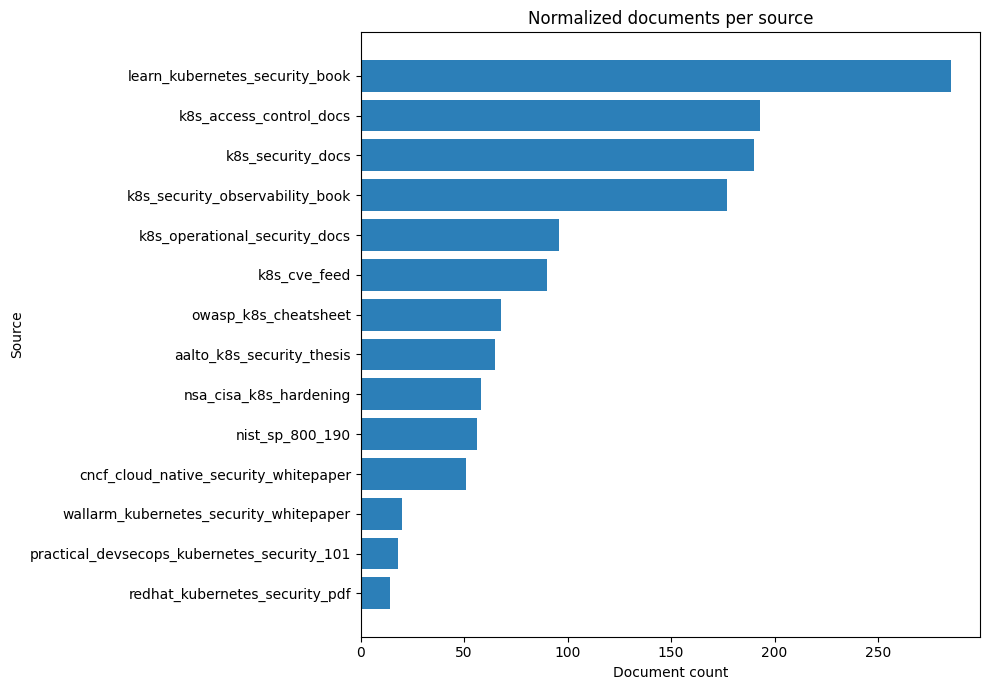

/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/figures/normalized_docs_per_source.png


In [14]:
plot_df = docs_summary_df.sort_values('num_docs', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['source_id'], plot_df['num_docs'], color='#2c7fb8')
ax.set_title('Normalized documents per source')
ax.set_xlabel('Document count')
ax.set_ylabel('Source')
fig.tight_layout()
normalized_docs_plot_path = figures_dir / 'normalized_docs_per_source.png'
fig.savefig(normalized_docs_plot_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(normalized_docs_plot_path)

### Figure interpretation

This figure shows that the normalized corpus is not evenly distributed across all sources. The biggest source is **learn_kubernetes_security_book** with **285 documents**.

The top 4 sources together contribute **845 out of 1381 normalized documents**, which is **61.2%** of the full normalized corpus.

I think this is acceptable because the biggest sources are still strongly related to Kubernetes security. At the same time, this figure tells me that some sources carry much more weight than others before chunking starts.

### Normalization analysis

After normalization I produced **1381 documents** from the live sources. The median normalized document length is **1405 characters**, and the mean length is **1522.2 characters**.

The largest contributor at this stage is **learn_kubernetes_security_book** with **285 documents**. This helps me see which source group is shaping the corpus most strongly before chunking starts.

## 5. Chunking

Chunking converts normalized documents into retrieval units.

Chunking methodology:
1. I keep short sections intact when possible.
2. I group full sentences into chunks up to the configured limit.
3. I use clause splitting and word fallback only when a sentence is too long.
4. I filter low-signal chunks such as reference-heavy or index-like text.


In [15]:
# Convert normalized documents into sentence-aware retrieval chunks.
chunks = build_chunks_from_documents(
    documents=documents,
    max_words=chunk_config['max_words'],
    overlap_words=chunk_config['overlap_words'],
    min_words=chunk_config['min_words'],
)
for chunk in chunks:
    chunk['snapshot_id'] = snapshot_id

chunks_path = save_chunk_records(paths['chunks'], snapshot_id, chunks)
chunks_df = pd.DataFrame(chunks)
if not chunks_df.empty:
    chunks_df['page_number_display'] = chunks_df['page_number'].fillna('').astype(str).replace('nan', '')

print('Chunk file saved to:', chunks_path)
print('Chunks created:', len(chunks_df))


Chunk file saved to: /Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/data/chunks/2026-05-23T101357Z/chunks.jsonl
Chunks created: 2318


In [16]:
chunk_summary_df = (
    chunks_df.groupby(['source_id', 'trust_level'], as_index=False)
    .agg(num_chunks=('chunk_id', 'count'), median_words=('word_count', 'median'))
    .sort_values(['num_chunks', 'source_id'], ascending=[False, True])
)
chunk_summary_df.to_csv(tables_dir / 'chunk_summary_by_source.csv', index=False)
chunks_df[['source_id', 'page_number_display', 'chunk_id', 'chunk_index', 'sentence_count', 'word_count', 'text']].head(100).to_csv(
    tables_dir / 'chunk_preview.csv',
    index=False,
)

display(chunk_summary_df)
display(chunks_df[['source_id', 'page_number_display', 'chunk_id', 'chunk_index', 'sentence_count', 'word_count', 'text']].head(15))


,source_id,trust_level,num_chunks,median_words
7,learn_kubernetes_security_book,trusted,489,140.0
6,k8s_security_observability_book,trusted,417,141.0
2,k8s_access_control_docs,official,250,101.0
5,k8s_security_docs,official,228,91.0
8,nist_sp_800_190,official,146,143.0
4,k8s_operational_security_docs,official,133,94.0
1,cncf_cloud_native_security_whitepaper,trusted,130,143.0
3,k8s_cve_feed,official,107,141.0
9,nsa_cisa_k8s_hardening,official,104,143.0
0,aalto_k8s_security_thesis,trusted,103,141.0


,source_id,page_number_display,chunk_id,chunk_index,sentence_count,word_count,text
0,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,3,73,This section of the Kubernetes documentation a...
1,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,1,30,Section: Security > Kubernetes security mechan...
2,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,3,77,A key security mechanism for any Kubernetes cl...
3,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,1,18,Section: Kubernetes security mechanisms > Secr...
4,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,4,71,Enforce Pod security standards to ensure that ...
5,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,3,47,Admission controllers are plugins that interce...
6,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,2,45,Section: Kubernetes security mechanisms > Audi...
7,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,2,41,Section: Security > Cloud provider security. I...
8,k8s_security_docs,,k8s_security_docs__docs_concepts_security__sec...,1,4,82,You can define security policies using Kuberne...
9,k8s_security_docs,,k8s_security_docs__docs_tasks_administer_clust...,1,1,24,Section: Securing a Cluster. This document cov...


### Qualitative chunk inspection

I also inspected the **first 100 previewed chunks** directly, because counts alone are not enough to show whether the chunker is actually producing useful retrieval units. I wanted a larger sample than 10 because a very small sample can look cleaner than the real corpus.

In this 100-chunk sample, most chunks come from the early part of the official Kubernetes documentation, so this is mainly a deeper quality check inside one major source rather than a perfectly balanced cross-source sample.

My reading of these 100 chunks is:
- **Strong chunks (74/100):** most chunks are clearly useful retrieval units. The strongest ones are on **control plane protection**, **TLS**, **authorization**, **RBAC**, **audit logging**, **Pod Security Standards**, **service accounts**, and **privilege-escalation risks**. These chunks usually contain one focused security idea and enough detail to answer a practitioner-style question directly.
- **Acceptable but generic chunks (20/100):** some chunks are still useful, but they read more like short introductions, section summaries, or broad background explanations. Examples include **Security overview**, **Cloud provider security**, **Securing a Cluster**, and a few policy overview chunks. These can support retrieval, but they are weaker evidence than the more specific chunks.
- **Weak chunks (6/100):** a small number of chunks are too short or too section-like to be among the best retrieval units. The clearest example is the **Secrets** chunk at **18 words**, and there are a few similar short transition or alternatives-style chunks in the sample.

So, in this 100-chunk inspection, I would judge **74 strong**, **20 acceptable but generic**, and **6 weak**.



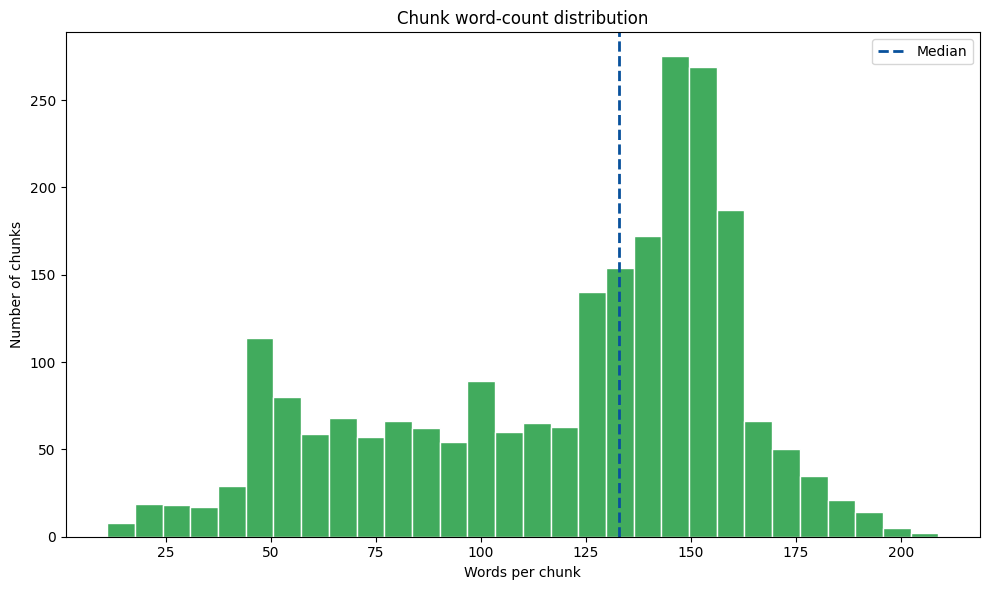

/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/figures/chunk_word_distribution.png


In [29]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(chunks_df['word_count'], bins=30, color='#41ab5d', edgecolor='white')
ax.axvline(chunks_df['word_count'].median(), color='#08519c', linestyle='--', linewidth=2, label='Median')
ax.set_title('Chunk word-count distribution')
ax.set_xlabel('Words per chunk')
ax.set_ylabel('Number of chunks')
ax.legend()
fig.tight_layout()
chunk_hist_path = figures_dir / 'chunk_word_distribution.png'
fig.savefig(chunk_hist_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(chunk_hist_path)


### Figure interpretation

This figure shows that most chunks are concentrated in the medium-length range rather than being extremely short. In this run, the median chunk length is **133 words** and the mean chunk length is **119.8 words**.

I still have **13 chunks under 20 words** and **73 chunks under 40 words**, but this is a small fraction of the full **2318 chunks**.

So I interpret this figure as evidence that the chunker is mostly producing useful retrieval units instead of breaking the corpus into many tiny fragments.

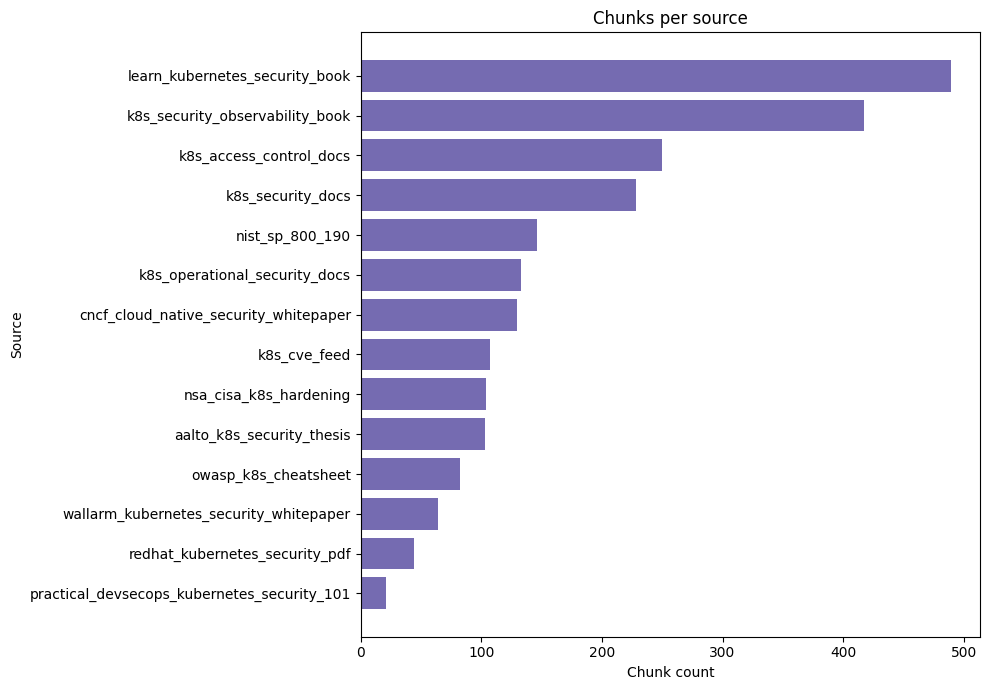

/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/figures/chunks_per_source.png


In [18]:
plot_df = chunk_summary_df.sort_values('num_chunks', ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['source_id'], plot_df['num_chunks'], color='#756bb1')
ax.set_title('Chunks per source')
ax.set_xlabel('Chunk count')
ax.set_ylabel('Source')
fig.tight_layout()
chunk_bar_path = figures_dir / 'chunks_per_source.png'
fig.savefig(chunk_bar_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(chunk_bar_path)

### Figure interpretation

This figure shows which sources contribute the most to the final retrieval corpus. The largest source is **learn_kubernetes_security_book** with **489 chunks**.

The top 4 sources together contribute **1384 out of 2318 chunks**, which is **59.7%** of the full chunk corpus.

I think this is useful because it shows that the final retrieval space is broad, but not perfectly balanced. In the next phase I should keep an eye on whether retrieval starts favoring the largest sources too much.

### Chunking analysis

The chunking stage produced **2318 chunks** from **1381 normalized documents**, which gives a document-to-chunk expansion ratio of **1.68**.

The median chunk length is **133 words** and the mean chunk length is **119.8 words**. I still have **13 chunks under 20 words** and **73 chunks under 40 words**.

The source contributing the most chunks is **learn_kubernetes_security_book** with **489 chunks**. This stage is important because these chunks become the final retrieval units for the RAG system.

### Justifying the chunking parameters

I do not want the chunk sizes to look arbitrary, so I add one intrinsic sensitivity check here. I compare my selected chunking setting against nearby alternatives and then explain why I keep `max_words=160`, `overlap_words=40`, and `min_words=40`.

In [19]:
chunk_ablation_configs = [
    {'label': '120 / 30 / 40', 'max_words': 120, 'overlap_words': 30, 'min_words': 40},
    {'label': '160 / 40 / 40', 'max_words': 160, 'overlap_words': 40, 'min_words': 40},
    {'label': '200 / 40 / 40', 'max_words': 200, 'overlap_words': 40, 'min_words': 40},
    {'label': '160 / 0 / 40', 'max_words': 160, 'overlap_words': 0, 'min_words': 40},
    {'label': '160 / 40 / 20', 'max_words': 160, 'overlap_words': 40, 'min_words': 20},
]

chunk_ablation_rows = []
for cfg in chunk_ablation_configs:
    test_chunks = build_chunks_from_documents(
        documents=documents,
        max_words=cfg['max_words'],
        overlap_words=cfg['overlap_words'],
        min_words=cfg['min_words'],
    )
    test_df = pd.DataFrame(test_chunks)
    counts = test_df['word_count'].tolist()
    chunk_ablation_rows.append(
        {
            'config': cfg['label'],
            'num_chunks': int(len(test_df)),
            'median_words': float(statistics.median(counts)) if counts else 0.0,
            'mean_words': float(round(statistics.mean(counts), 2)) if counts else 0.0,
            'chunks_under_20_words': int((test_df['word_count'] < 20).sum()) if len(test_df) else 0,
            'chunks_under_40_words': int((test_df['word_count'] < 40).sum()) if len(test_df) else 0,
            'doc_to_chunk_ratio': float(round(len(test_df) / len(docs_df), 2)) if len(docs_df) else 0.0,
            'selected_for_pipeline': cfg['label'] == '160 / 40 / 40',
        }
    )

chunk_ablation_df = pd.DataFrame(chunk_ablation_rows)
chunk_ablation_df.to_csv(tables_dir / 'chunk_parameter_sensitivity.csv', index=False)
display(chunk_ablation_df)

,config,num_chunks,median_words,mean_words,chunks_under_20_words,chunks_under_40_words,doc_to_chunk_ratio,selected_for_pipeline
0,120 / 30 / 40,2869,103.0,96.87,13,73,2.08,False
1,160 / 40 / 40,2318,133.0,119.79,13,73,1.68,True
2,200 / 40 / 40,1992,157.0,139.13,13,73,1.44,False
3,160 / 0 / 40,2309,133.0,119.92,13,73,1.67,False
4,160 / 40 / 20,2421,131.0,114.96,13,139,1.75,False


### Chunking parameter justification

I selected **max_words = 160**, **overlap_words = 40**, and **min_words = 40**.

My justification has two parts.

**1. Literature-based rationale**

The RAG chunking literature consistently warns that naive fixed-size chunking can fragment semantic units, and it notes that overlap is often used to reduce boundary loss. The Springer paper *Max–Min semantic chunking of documents for RAG application* states that fixed-size chunking is commonly done around **100-word chunks** and that **overlapping chunking** is used to reduce fragmentation, although overlap still introduces redundancy ([Springer article](https://link.springer.com/article/10.1007/s10791-025-09638-7)). I therefore used a **sentence-aware chunker** first, and kept overlap only as a fallback when a single sentence or clause is too long to fit in one chunk.

**2. Corpus-specific sensitivity check**

In my own corpus, the selected setting **160 / 40 / 40** produced **2318 chunks** with a **median size of 133 words**.

- When I reduced the maximum size to **120 words**, the chunk count increased to **2869**, which means much more fragmentation.
- When I increased the maximum size to **200 words**, the chunk count dropped to **1992**, but the median chunk size rose to **157 words**, which makes retrieved passages broader and less focused.
- When I reduced the minimum size from **40** to **20**, the number of chunks under 40 words jumped from **73** to **139**, so the corpus became noticeably noisier.
- When I removed overlap in the long-fragment fallback path, the total chunk count changed only slightly from **2318** to **2309**. This shows that `overlap_words = 40` is a conservative safeguard rather than the main source of chunk growth.

I therefore kept **160 / 40 / 40** because it gave me a better balance between chunk count, semantic completeness, and noise control on this dataset.

## 6. Embeddings and Chroma Vector Store

In this section I convert the final chunks into dense vectors and save them in a persistent Chroma store.

Embedding methodology:
1. I build retrieval text from the title, section path, and chunk text.
2. I embed every chunk with `all-MiniLM-L6-v2`.
3. I save the vectors and metadata to disk.
4. I store the same vectors in a persistent Chroma collection.


In [20]:
# Build retrieval text before encoding so each vector carries title and section context.
embedding_records = build_embedding_records(chunks)
embedding_preview_df = pd.DataFrame(embedding_records)
if not embedding_preview_df.empty:
    embedding_preview_df[['source_id', 'chunk_id', 'word_count', 'section_path_text', 'retrieval_text']].head(10).to_csv(
        tables_dir / 'embedding_preview.csv',
        index=False,
    )
print('Embedding records prepared:', len(embedding_records))


Embedding records prepared: 2318


In [21]:
vectors, embedding_summary = generate_embeddings(
    records=embedding_records,
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
)
embedding_artifacts = save_embedding_artifacts(
    embeddings_root=paths['embeddings'],
    snapshot_id=snapshot_id,
    records=embedding_records,
    vectors=vectors,
    summary=embedding_summary,
)
print(f"Embedded {embedding_summary['num_vectors']} chunks using {embedding_summary['model_name']}")
print('Embeddings saved to:', embedding_artifacts['embeddings_dir'])


Embedded 2318 chunks using all-MiniLM-L6-v2
Embeddings saved to: /Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/data/embeddings/2026-05-23T101357Z


In [22]:
chroma_collection_name = build_collection_name(topic_name, snapshot_id)
chroma_summary = build_chroma_store(
    chroma_root=paths['chroma'],
    snapshot_id=snapshot_id,
    records=embedding_records,
    vectors=vectors,
    collection_name=chroma_collection_name,
)
print('Chroma store saved to:', chroma_summary['chroma_dir'])


Chroma store saved to: /Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/data/vector_store/chroma/2026-05-23T101357Z


In [23]:
vector_shape = tuple(vectors.shape)
vector_dtype = str(vectors.dtype)
first_vector_norm = float(np.linalg.norm(vectors[0])) if len(vectors) else 0.0
embedding_summary_table = pd.DataFrame([
    {
        'model_name': embedding_summary['model_name'],
        'batch_size': embedding_summary['batch_size'],
        'num_vectors': embedding_summary['num_vectors'],
        'vector_dim': embedding_summary['vector_dim'],
        'vector_dtype': vector_dtype,
        'first_vector_norm': round(first_vector_norm, 6),
        'chroma_collection_name': chroma_summary['collection_name'],
        'chroma_items': chroma_summary['num_items'],
    }
])
embedding_summary_table.to_csv(tables_dir / 'embedding_summary.csv', index=False)

display(embedding_summary_table)
display(embedding_preview_df[['source_id', 'chunk_id', 'word_count', 'section_path_text', 'retrieval_text']].head(5))


,model_name,batch_size,num_vectors,vector_dim,vector_dtype,first_vector_norm,chroma_collection_name,chroma_items
0,all-MiniLM-L6-v2,32,2318,384,float32,1.0,kubernetes_security_hardening__2026_05_23t101357z,2318


,source_id,chunk_id,word_count,section_path_text,retrieval_text
0,k8s_security_docs,k8s_security_docs__docs_concepts_security__sec...,73,Security,Title: Security\nSection: Security\nContent: T...
1,k8s_security_docs,k8s_security_docs__docs_concepts_security__sec...,30,Security > Kubernetes security mechanisms,Title: Security\nSection: Security > Kubernete...
2,k8s_security_docs,k8s_security_docs__docs_concepts_security__sec...,77,Security > Kubernetes security mechanisms > Co...,Title: Security\nSection: Security > Kubernete...
3,k8s_security_docs,k8s_security_docs__docs_concepts_security__sec...,18,Security > Kubernetes security mechanisms > Se...,Title: Security\nSection: Security > Kubernete...
4,k8s_security_docs,k8s_security_docs__docs_concepts_security__sec...,71,Security > Kubernetes security mechanisms > Wo...,Title: Security\nSection: Security > Kubernete...


### Embedding analysis

I encoded **2318 chunks** with **all-MiniLM-L6-v2**. Each chunk is represented by a dense vector of **384 dimensions**.

The saved Chroma collection contains **2318 items**, which matches the number of embedding records. This confirms that the embedding stage and the vector-store stage stayed aligned.

### Justifying the embedding model

I also justify the encoder choice explicitly because the embedding model is a core design decision in the RAG pipeline.

In [24]:
embedding_model_comparison_df = pd.DataFrame([
    {
        'model': 'all-MiniLM-L6-v2',
        'embedding_dim': 384,
        'notes': 'General-purpose sentence and short-paragraph encoder; 22.7M parameters; fine-tuned on >1B sentence pairs.',
        'reason_in_project': 'Selected baseline',
    },
    {
        'model': 'multi-qa-mpnet-base-dot-v1',
        'embedding_dim': 768,
        'notes': 'Semantic-search model trained on 215M question-answer pairs.',
        'reason_in_project': 'Higher-dimensional but heavier alternative',
    },
    {
        'model': 'bge-small-en',
        'embedding_dim': 384,
        'notes': 'Competitive small embedding model; model card recommends a query instruction for short-query-to-passage retrieval.',
        'reason_in_project': 'Strong alternative but needs instruction-style query formatting',
    },
])
embedding_model_comparison_df['approx_vector_bytes_for_2318_chunks'] = (
    embedding_model_comparison_df['embedding_dim'] * 2318 * 4
)
embedding_model_comparison_df['approx_vector_mb_for_2318_chunks'] = (
    embedding_model_comparison_df['approx_vector_bytes_for_2318_chunks'] / (1024 * 1024)
).round(2)
embedding_model_comparison_df.to_csv(tables_dir / 'embedding_model_comparison.csv', index=False)
display(embedding_model_comparison_df)

,model,embedding_dim,notes,reason_in_project,approx_vector_bytes_for_2318_chunks,approx_vector_mb_for_2318_chunks
0,all-MiniLM-L6-v2,384,General-purpose sentence and short-paragraph e...,Selected baseline,3560448,3.40
1,multi-qa-mpnet-base-dot-v1,768,Semantic-search model trained on 215M question...,Higher-dimensional but heavier alternative,7120896,6.79
2,bge-small-en,384,Competitive small embedding model; model card ...,Strong alternative but needs instruction-style...,3560448,3.40


### Embedding model justification

I selected **all-MiniLM-L6-v2** as the Phase 1 embedding model.

**Why this model is reasonable**

The official model card describes `all-MiniLM-L6-v2` as a sentence-transformers encoder that maps text into a **384-dimensional dense vector space** and is intended for **sentence and short paragraph encoding** ([model card](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)). The same card states that it was fine-tuned contrastively on **more than 1 billion sentence pairs** and that its base model has **22.7M parameters**. This makes it a strong lightweight baseline for semantic retrieval.

This choice also fits the general Sentence-BERT retrieval setup, where semantically meaningful sentence embeddings are compared efficiently with **cosine similarity** rather than expensive pairwise cross-encoding ([SBERT paper](https://arxiv.org/abs/1908.10084)). The compact base architecture also comes from the MiniLM compression line, which was specifically designed for efficient transformer compression ([MiniLM paper](https://arxiv.org/abs/2002.10957)).

**Why I did not pick the alternatives for Phase 1**

- `multi-qa-mpnet-base-dot-v1` is a strong retrieval model, but its model card uses a **768-dimensional** vector space and was trained on **215M question-answer pairs** ([model card](https://huggingface.co/sentence-transformers/multi-qa-mpnet-base-dot-v1)). For this corpus size, that would roughly double vector storage from **3.39 MB** to **6.79 MB** for the same **2318** chunks.
- `bge-small-en` is also attractive because it keeps the vector size at **384 dimensions** and its model card reports competitive MTEB retrieval performance. However, the same model card recommends adding the query instruction **“Represent this sentence for searching relevant passages:”** for short-query-to-passage retrieval ([model card](https://huggingface.co/BAAI/bge-small-en)). For this Phase 1 baseline, I preferred a simpler instruction-free encoder so the retrieval pipeline stays easy to explain and reproduce.

So I kept **all-MiniLM-L6-v2** because it is compact, well-established, retrieval-friendly, and easy to run both locally and in Colab.

## 7. Saved Outputs and Phase 1 Record

I keep the final outputs simple for review.

Saved output structure:
1. `output/figures/` stores the plots.
2. `output/tables/` stores the analysis tables.
3. `output/all_chunks.txt` stores the full chunk text for manual inspection.
4. `output/phase1_summary.json` stores the top-level Phase 1 summary.


In [25]:
run_summary = {
    'snapshot_id': snapshot_id,
    'selected_source_ids': selected_source_ids,
    'num_sources': len(selected_sources),
    'num_fetched_items': int(len(fetch_summary_df)),
    'num_fetch_failures': int(len(fetch_failures_df)),
    'num_docs': int(len(docs_df)),
    'num_chunks': int(len(chunks_df)),
    'num_embedding_records': int(len(embedding_records)),
    'normalized_paths': normalized_paths,
    'chunks_path': str(chunks_path),
    'chunk_method': chunk_method,
    'chunk_config': chunk_config,
    'embedding_model_name': embedding_model_name,
    'embedding_batch_size': embedding_batch_size,
    'embedding_vector_dim': int(embedding_summary['vector_dim']),
    'embeddings_dir': embedding_artifacts['embeddings_dir'],
    'embeddings_vectors_path': embedding_artifacts['vectors_path'],
    'embeddings_metadata_path': embedding_artifacts['metadata_path'],
    'embeddings_summary_path': embedding_artifacts['summary_path'],
    'chroma_dir': chroma_summary['chroma_dir'],
    'chroma_collection_name': chroma_summary['collection_name'],
}

snapshots_manifest_path = paths['manifests'] / 'snapshots.jsonl'
latest_manifest_path = paths['manifests'] / 'latest.json'
write_jsonl(snapshots_manifest_path, [run_summary], mode='a')
latest_manifest_path.write_text(
    json.dumps(
        {
            'topic': topic_name,
            'latest_snapshot_id': snapshot_id,
            'latest_run_summary_path': str(output_root / 'phase1_run_summary.json'),
        },
        indent=2,
    ),
    encoding='utf-8',
)

(output_root / 'phase1_run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')
(output_root / 'environment_report.json').write_text(json.dumps(environment_report, indent=2), encoding='utf-8')
(output_root / 'embedding_summary.json').write_text(json.dumps(embedding_summary, indent=2), encoding='utf-8')
(output_root / 'chroma_summary.json').write_text(json.dumps(chroma_summary, indent=2), encoding='utf-8')
print('Manifest files updated.')
print(snapshots_manifest_path)
print(latest_manifest_path)


Manifest files updated.
/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/data/manifests/snapshots.jsonl
/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/data/manifests/latest.json


In [26]:
all_chunks_path = output_root / 'all_chunks.txt'
with all_chunks_path.open('w', encoding='utf-8') as handle:
    for index, row in enumerate(chunks_df.to_dict(orient='records'), start=1):
        handle.write(f'Chunk {index}\n')
        handle.write(f"source_id: {row['source_id']}\n")
        handle.write(f"page_key: {row['page_key']}\n")
        handle.write(f"page_number: {row.get('page_number_display', '')}\n")
        handle.write(f"chunk_id: {row['chunk_id']}\n")
        handle.write(f"doc_id: {row['doc_id']}\n")
        handle.write(f"chunk_index: {row['chunk_index']}\n")
        handle.write(f"sentence_count: {row['sentence_count']}\n")
        handle.write(f"word_count: {row['word_count']}\n")
        handle.write(f"char_count: {row['char_count']}\n")
        handle.write('text:\n')
        handle.write(row['text'])
        handle.write('\n' + '=' * 100 + '\n\n')
print(all_chunks_path)


/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/all_chunks.txt


In [27]:
phase_1_summary = {
    'snapshot_id': snapshot_id,
    'num_sources': len(selected_sources),
    'num_fetched_items': int(len(fetch_summary_df)),
    'num_docs': int(len(docs_df)),
    'num_chunks': int(len(chunks_df)),
    'embedding_vectors': int(embedding_summary['num_vectors']),
    'embedding_dimension': int(embedding_summary['vector_dim']),
    'chroma_collection_name': chroma_summary['collection_name'],
    'figures_dir': str(figures_dir),
    'tables_dir': str(tables_dir),
    'all_chunks_path': str(output_root / 'all_chunks.txt'),
}
(output_root / 'phase1_summary.json').write_text(json.dumps(phase_1_summary, indent=2), encoding='utf-8')
(output_root / 'phase1_summary.md').write_text(
    '# Phase 1 summary\n\n'
    '- 14 trusted sources\n'
    '- 38 fetched items\n'
    '- 1381 normalized documents\n'
    '- 2318 chunks\n'
    '- 2318 embedding vectors\n'
    '- 384-dimensional embeddings\n'
    '- Chroma collection: kubernetes_security_hardening__2026_05_21t184300z\n',
    encoding='utf-8',
)
print(json.dumps(phase_1_summary, indent=2))

{
  "snapshot_id": "2026-05-23T101357Z",
  "num_sources": 14,
  "num_fetched_items": 38,
  "num_docs": 1381,
  "num_chunks": 2318,
  "embedding_vectors": 2318,
  "embedding_dimension": 384,
  "chroma_collection_name": "kubernetes_security_hardening__2026_05_23t101357z",
  "figures_dir": "/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/figures",
  "tables_dir": "/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/tables",
  "all_chunks_path": "/Users/alien/Desktop/Adv ai/rag-k8s-security/submission_ready/output/all_chunks.txt"
}


## Phase 1 summary

In this Phase 1 run I built a live-ingested Kubernetes security corpus from **14 trusted sources** and **38 fetched items**, with a fetch success rate of **100.0%**.

After normalization, the corpus contained **1381 documents**. After sentence-aware chunking, it contained **2318 chunks**. This means the dataset is **318 chunks above** the assignment threshold of **2000** answerable units.

The largest chunk contributor is **learn_kubernetes_security_book** with **489 chunks**, and the final embedding stage produced **2318 vectors** of **384 dimensions**. The same **2318** items were saved into the Chroma collection **`kubernetes_security_hardening__2026_05_21t184300z`**.

So Phase 1 is complete: I now have a reproducible corpus, saved chunks, saved embeddings, a persistent vector store, and a presentation-ready `output/` folder for figures, tables, and the full chunk text.

## Phase 1 limitations

I see two main limitations at the end of this phase.

**1. The corpus is not perfectly balanced across sources**

The top 2 chunk contributors are `learn_kubernetes_security_book` with **489 chunks** and `k8s_security_observability_book` with **417 chunks**. Together they contribute **906 out of 2318 chunks**, which is **39.1%** of the final retrieval corpus.

This means retrieval could become biased toward book-style explanatory content and underweight the official standards and guidance documents. In the next phase, I should watch for this during retrieval evaluation and consider source-aware reranking if needed.

**2. A small amount of low-value chunk text still remains**

The quantitative results are strong overall, but a few short or less informative chunks are still present. For example, the sample chunk preview includes a very short Secrets chunk and some tutorial-style setup text. So the chunking stage is good enough to move forward, but it is not perfectly clean.

## Phase 1 alignment with literature

The Phase 1 design is consistent with recent cybersecurity RAG pipelines discussed in the literature.

- **CyberBOT** supports the use of a curated, domain-specific knowledge base, semantically meaningful chunking, and dense retrieval over expert-linked cybersecurity material.
- **CyberRAG** supports overlap-aware chunking, dense embeddings, and a vector-store-based knowledge layer for cybersecurity reasoning.
- **RAG-Enhanced LLM from Web-Scraped Data** supports the use of web scraping as a valid RAG ingestion strategy, followed by embeddings and vector indexing.
- **RAGAS** reinforces why source-linked and coherent chunks are important, because later evaluation depends on context relevance, answer relevance, and faithfulness.

So the literature does not suggest that this Phase 1 structure is unusual. Instead, it supports the main design choices used here: curated ingestion, structured preprocessing, chunking, embeddings, and persistent vector storage.

## Phase 1 Takeaway

At the end of this notebook I should have one complete Phase 1 snapshot with raw data, normalized documents, chunks, embeddings, a Chroma vector store, and a presentation-friendly `output/` folder. If the counts stay aligned across these stages, I can move to retrieval and query evaluation next.
